# COVID-19 Detection from Chest X-rays using CNN

## Objective

Build deep learning models to classify chest X-ray images into:

1. COVID-19
2. Normal
3. Viral Pneumonia

The project compares CNN models built from scratch with pretrained architectures such as VGG16 and ResNet50, with and without data augmentation.

In [1]:
import os
import zipfile
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("GPUs available:", gpus)

TensorFlow version: 2.21.0
GPUs available: []


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
ZIP_PATH = "Covid19-dataset.zip"
EXTRACT_PATH = "data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
BASE_DIR = "data/Covid19-dataset"

print(os.listdir(BASE_DIR))

['test', 'train']


In [6]:
print("Train classes:")
print(os.listdir(os.path.join(BASE_DIR, "train")))

print("\nTest classes:")
print(os.listdir(os.path.join(BASE_DIR, "test")))

Train classes:
['Covid', 'Normal', 'Viral Pneumonia']

Test classes:
['Covid', 'Normal', 'Viral Pneumonia']


In [7]:
classes = ["Covid", "Normal", "Viral Pneumonia"]

for split in ["train", "test"]:

    print(f"\n{split.upper()} DATASET")

    for class_name in classes:

        folder = os.path.join(
            BASE_DIR,
            split,
            class_name
        )

        count = len([
            file for file in os.listdir(folder)
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

        print(f"{class_name}: {count}")


TRAIN DATASET
Covid: 111
Normal: 70
Viral Pneumonia: 70

TEST DATASET
Covid: 26
Normal: 20
Viral Pneumonia: 20


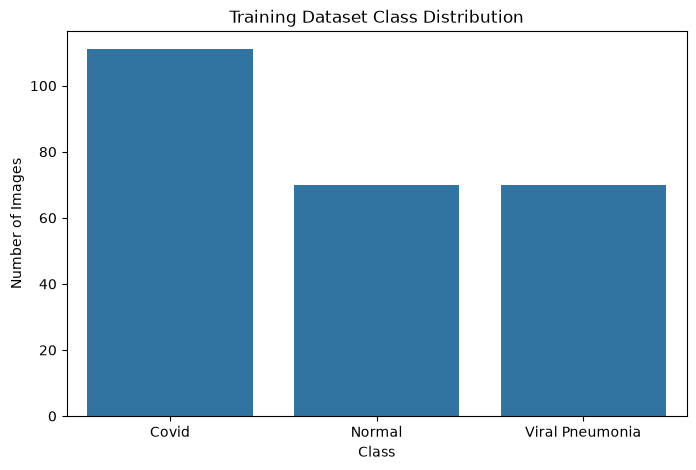

In [8]:
train_counts = []

for class_name in classes:

    folder = os.path.join(
        BASE_DIR,
        "train",
        class_name
    )

    count = len([
        file for file in os.listdir(folder)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    train_counts.append(count)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=classes,
    y=train_counts
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [9]:
image_path = os.path.join(
    BASE_DIR,
    "train",
    "Covid",
    os.listdir(
        os.path.join(
            BASE_DIR,
            "train",
            "Covid"
        )
    )[0]
)

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (4248, 3480)
Image mode: RGB


In [10]:
def show_sample_images(class_name, num_images=5):

    folder = os.path.join(
        BASE_DIR,
        "train",
        class_name
    )

    image_files = [
        file for file in os.listdir(folder)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    selected_images = random.sample(
        image_files,
        min(num_images, len(image_files))
    )

    plt.figure(figsize=(15, 3))

    for i, image_file in enumerate(selected_images):

        image_path = os.path.join(
            folder,
            image_file
        )

        image = Image.open(image_path).convert("RGB")

        plt.subplot(1, num_images, i + 1)

        plt.imshow(image)

        plt.title(class_name)

        plt.axis("off")

    plt.show()

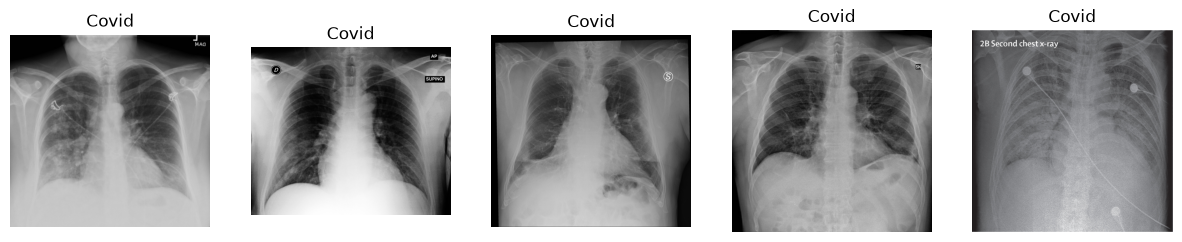

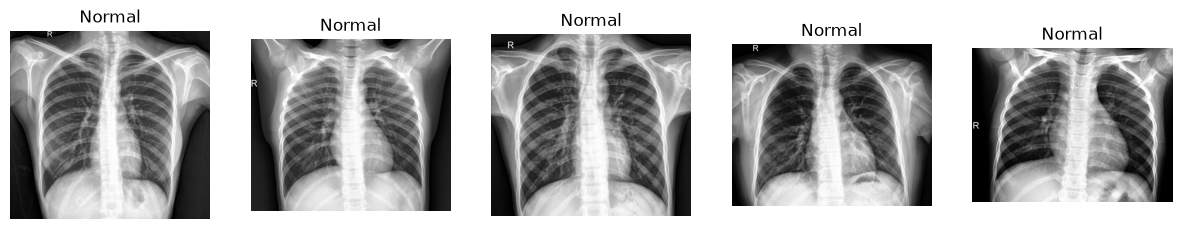

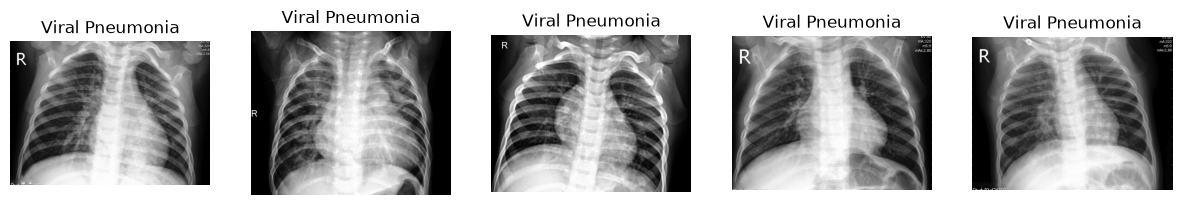

In [11]:
show_sample_images("Covid")
show_sample_images("Normal")
show_sample_images("Viral Pneumonia")

In [12]:
data = []

for split in ["train", "test"]:

    split_path = os.path.join(
        BASE_DIR,
        split
    )

    for class_name in classes:

        class_path = os.path.join(
            split_path,
            class_name
        )

        for image_file in os.listdir(class_path):

            if image_file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                data.append({
                    "image_path": os.path.join(
                        class_path,
                        image_file
                    ),
                    "label": class_name,
                    "split": split
                })

df = pd.DataFrame(data)

df.head()

,image_path,label,split
0,data/Covid19-dataset\train\Covid\01.jpeg,Covid,train
1,data/Covid19-dataset\train\Covid\010.png,Covid,train
2,data/Covid19-dataset\train\Covid\012.jpeg,Covid,train
3,data/Covid19-dataset\train\Covid\015.jpg,Covid,train
4,data/Covid19-dataset\train\Covid\019.png,Covid,train


In [13]:
print("Total images:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nSplit distribution:")
print(df["split"].value_counts())

Total images: 317

Class distribution:
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64

Split distribution:
split
train    251
test      66
Name: count, dtype: int64


In [14]:
train_df = df[df["split"] == "train"].copy()

test_df = df[df["split"] == "test"].copy()

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"]
)

In [15]:
print("Training:")
print(train_data["label"].value_counts())

print("\nValidation:")
print(val_data["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())

Training:
label
Covid              88
Normal             56
Viral Pneumonia    56
Name: count, dtype: int64

Validation:
label
Covid              23
Normal             14
Viral Pneumonia    14
Name: count, dtype: int64

Test:
label
Covid              26
Normal             20
Viral Pneumonia    20
Name: count, dtype: int64


In [16]:
IMG_SIZE = 224

label_map = {
    "Covid": 0,
    "Normal": 1,
    "Viral Pneumonia": 2
}

In [17]:
def load_images(dataframe, image_size=224):

    images = []
    labels = []

    for _, row in dataframe.iterrows():

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = image.resize(
            (image_size, image_size)
        )

        image = np.array(image)

        image = image / 255.0

        images.append(image)

        labels.append(
            label_map[row["label"]]
        )

    return np.array(images), np.array(labels)

In [19]:
X_train, y_train = load_images(train_data)

X_val, y_val = load_images(val_data)

X_test, y_test = load_images(test_df)

In [20]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (200, 224, 224, 3)
y_train: (200,)
X_val: (51, 224, 224, 3)
y_val: (51,)
X_test: (66, 224, 224, 3)
y_test: (66,)


In [21]:
y_train_cat = keras.utils.to_categorical(
    y_train,
    num_classes=3
)

y_val_cat = keras.utils.to_categorical(
    y_val,
    num_classes=3
)

y_test_cat = keras.utils.to_categorical(
    y_test,
    num_classes=3
)

In [22]:
basic_cnn = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

In [23]:
basic_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
basic_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,779 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
history_basic = basic_cnn.fit(
    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,
    batch_size=16,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.9950 - loss: 0.0575 - val_accuracy: 0.9020 - val_loss: 0.2523
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 433ms/step - accuracy: 0.9750 - loss: 0.0813 - val_accuracy: 0.9020 - val_loss: 0.2389
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.9850 - loss: 0.0646 - val_accuracy: 0.9412 - val_loss: 0.1776
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 499ms/step - accuracy: 0.9950 - loss: 0.0363 - val_accuracy: 0.9020 - val_loss: 0.2410
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.9850 - loss: 0.0621 - val_accuracy: 0.9412 - val_loss: 0.2349
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 415ms/step - accuracy: 0.9850 - loss: 0.0679 - val_accuracy: 0.9020 - val_loss: 0.1886
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.9900 - loss: 0.0513 - val_accuracy: 0.9412 - val_loss: 0.2126
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 0.9850 - loss: 0.0400 - val_accuracy: 0.

In [28]:
def plot_history(history, title):

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(title + " - Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()


    plt.subplot(1, 2, 2)

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(title + " - Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.show()

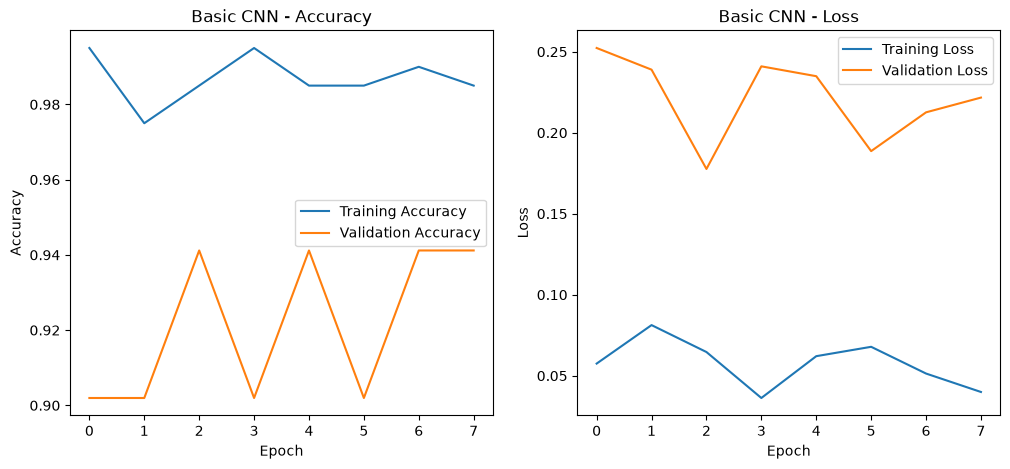

In [29]:
plot_history(
    history_basic,
    "Basic CNN"
)

In [30]:
test_loss, test_accuracy = basic_cnn.evaluate(
    X_test,
    y_test_cat
)

print(
    "Test Accuracy:",
    test_accuracy
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8939 - loss: 0.2651
Test Accuracy: 0.8939393758773804


In [31]:
y_prob_basic = basic_cnn.predict(
    X_test
)

y_pred_basic = np.argmax(
    y_prob_basic,
    axis=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [32]:
print(
    classification_report(
        y_test,
        y_pred_basic,
        target_names=classes
    )
)

                 precision    recall  f1-score   support

          Covid       1.00      0.96      0.98        26
         Normal       0.78      0.90      0.84        20
Viral Pneumonia       0.89      0.80      0.84        20

       accuracy                           0.89        66
      macro avg       0.89      0.89      0.89        66
   weighted avg       0.90      0.89      0.90        66



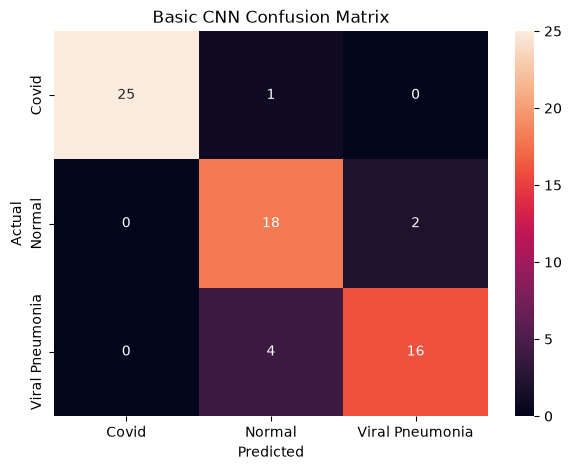

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred_basic
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Basic CNN Confusion Matrix")

plt.show()

In [34]:
deep_cnn = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

In [35]:
deep_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
history_deep = deep_cnn.fit(
    X_train,
    y_train_cat,
    validation_data=(
        X_val,
        y_val_cat
    ),
    epochs=30,
    batch_size=16,
    callbacks=[
        early_stopping
    ]
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 693ms/step - accuracy: 0.5450 - loss: 1.0143 - val_accuracy: 0.2745 - val_loss: 1.0979
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 777ms/step - accuracy: 0.7050 - loss: 0.6910 - val_accuracy: 0.4510 - val_loss: 1.0760
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 726ms/step - accuracy: 0.7600 - loss: 0.5958 - val_accuracy: 0.4510 - val_loss: 1.0650
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 743ms/step - accuracy: 0.7900 - loss: 0.5617 - val_accuracy: 0.4510 - val_loss: 1.0717
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 733ms/step - accuracy: 0.8150 - loss: 0.4839 - val_accuracy: 0.4510 - val_loss: 1.0988
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 751ms/step - accuracy: 0.8800 - loss: 0.4223 - val_accuracy: 0.4510 - val_loss: 1.1399
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 760ms/step - accuracy: 0.8850 - loss: 0.3962 - val_accuracy: 0.4510 - val_loss: 1.2040
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 743ms/step - accuracy: 0.8650 - loss: 0.4049 - val_accur

In [37]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [38]:
vgg_base.trainable = False

In [39]:
from tensorflow.keras.applications.vgg16 import preprocess_input

vgg_model = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Lambda(
        preprocess_input
    ),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

In [40]:
vgg_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
history_vgg = vgg_model.fit(
    X_train * 255.0,
    y_train_cat,

    validation_data=(
        X_val * 255.0,
        y_val_cat
    ),

    epochs=15,

    batch_size=16,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3500 - loss: 7.8031 - val_accuracy: 0.4510 - val_loss: 3.6729
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.3950 - loss: 5.6611 - val_accuracy: 0.5098 - val_loss: 2.2316
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4150 - loss: 4.4814 - val_accuracy: 0.5490 - val_loss: 1.7015
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.4600 - loss: 3.7952 - val_accuracy: 0.5686 - val_loss: 1.3719
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.4900 - loss: 3.0883 - val_accuracy: 0.7255 - val_loss: 1.1978
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5750 - loss: 2.6391 - val_accuracy: 0.7255 - val_loss: 1.0143
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5700 - loss: 2.8416 - val_accuracy: 0.7451 - val_loss: 0.7760
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6550 - loss: 1.8609 - val_accuracy: 0.7647 - val_loss:

In [42]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [43]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [44]:
resnet_model = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Lambda(
        preprocess_input
    ),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

In [45]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
history_resnet = resnet_model.fit(
    X_train * 255.0,
    y_train_cat,

    validation_data=(
        X_val * 255.0,
        y_val_cat
    ),

    epochs=15,

    batch_size=16,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4150 - loss: 1.3695 - val_accuracy: 0.6667 - val_loss: 0.6875
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6800 - loss: 0.7366 - val_accuracy: 0.8431 - val_loss: 0.4719
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7850 - loss: 0.5108 - val_accuracy: 0.9020 - val_loss: 0.3910
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8300 - loss: 0.4364 - val_accuracy: 0.9216 - val_loss: 0.3287
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8650 - loss: 0.3731 - val_accuracy: 0.9216 - val_loss: 0.3110
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9100 - loss: 0.2893 - val_accuracy: 0.9216 - val_loss: 0.3037
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9250 - loss: 0.2376 - val_accuracy: 0.9216 - val_loss: 0.2833
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9200 - loss: 0.2490 - val_accuracy: 0.9216 - val_loss:

In [47]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-20]:
    layer.trainable = False

In [48]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
history_resnet_finetune = resnet_model.fit(
    X_train * 255.0,
    y_train_cat,

    validation_data=(
        X_val * 255.0,
        y_val_cat
    ),

    epochs=10,

    batch_size=16,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9400 - loss: 0.1803 - val_accuracy: 0.9216 - val_loss: 0.2607
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9700 - loss: 0.1154 - val_accuracy: 0.9216 - val_loss: 0.2759
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9950 - loss: 0.0875 - val_accuracy: 0.9216 - val_loss: 0.2772
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9850 - loss: 0.0858 - val_accuracy: 0.9216 - val_loss: 0.2747
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9850 - loss: 0.0729 - val_accuracy: 0.9216 - val_loss: 0.2716
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 1.0000 - loss: 0.0551 - val_accuracy: 0.9216 - val_loss: 0.2736


In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [51]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

In [52]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights_array)
)

print(class_weights)

{0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


In [53]:
class_weight=class_weights

In [54]:
augmentation = keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    layers.RandomZoom(0.10),

    layers.RandomFlip("horizontal")
])

In [55]:
resnet_augmented = keras.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    augmentation,

    layers.Lambda(
        preprocess_input
    ),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation="softmax"
    )
])

In [56]:
augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(
        0.05,
        0.05
    ),
    layers.RandomZoom(0.10)
])

In [58]:
def evaluate_model(
    model,
    X_test_input,
    y_test,
    y_test_cat,
    model_name
):

    probabilities = model.predict(
        X_test_input,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = np.mean(
        predictions == y_test
    )

    f1 = classification_report(
        y_test,
        predictions,
        output_dict=True
    )["weighted avg"]["f1-score"]

    auc_score = roc_auc_score(
        y_test_cat,
        probabilities,
        multi_class="ovr"
    )

    print("\n", "=" * 50)

    print(model_name)

    print("=" * 50)

    print(
        f"Test Accuracy: {accuracy:.4f}"
    )

    print(
        f"Weighted F1 Score: {f1:.4f}"
    )

    print(
        f"ROC-AUC: {auc_score:.4f}"
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=classes
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    return {
        "Model": model_name,
        "Test Accuracy": accuracy,
        "F1 Score": f1,
        "ROC-AUC": auc_score
    }


Basic CNN
Test Accuracy: 0.8939
Weighted F1 Score: 0.8951
ROC-AUC: 0.9707

Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      0.96      0.98        26
         Normal       0.78      0.90      0.84        20
Viral Pneumonia       0.89      0.80      0.84        20

       accuracy                           0.89        66
      macro avg       0.89      0.89      0.89        66
   weighted avg       0.90      0.89      0.90        66



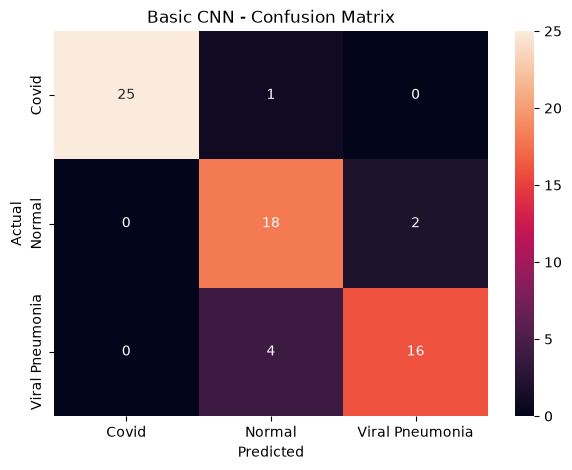

In [59]:
result_basic = evaluate_model(
    basic_cnn,
    X_test,
    y_test,
    y_test_cat,
    "Basic CNN"
)


Deep CNN
Test Accuracy: 0.3939
Weighted F1 Score: 0.2227
ROC-AUC: 0.5309

Classification Report:

                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.39        66
      macro avg       0.13      0.33      0.19        66
   weighted avg       0.16      0.39      0.22        66



d:\CNN mini project\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CNN mini project\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CNN mini project\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CNN mini project\myenv

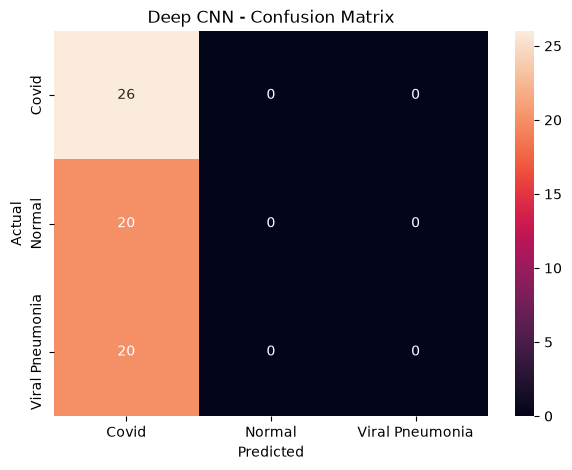

In [60]:
result_deep = evaluate_model(
    deep_cnn,
    X_test,
    y_test,
    y_test_cat,
    "Deep CNN"
)


ResNet50
Test Accuracy: 0.9697
Weighted F1 Score: 0.9696
ROC-AUC: 0.9964

Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.90      0.95        20
Viral Pneumonia       0.91      1.00      0.95        20

       accuracy                           0.97        66
      macro avg       0.97      0.97      0.97        66
   weighted avg       0.97      0.97      0.97        66



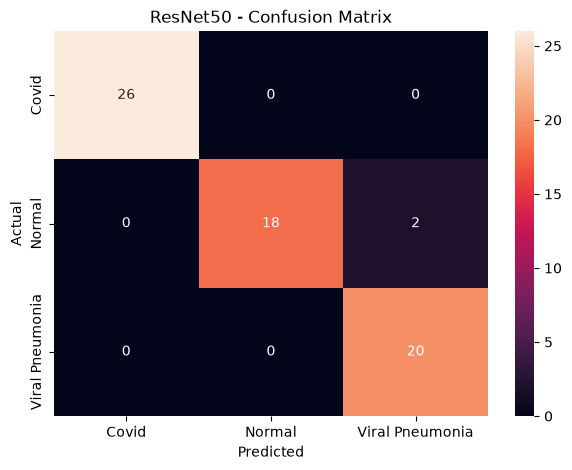

In [61]:
result_resnet = evaluate_model(
    resnet_model,
    X_test * 255.0,
    y_test,
    y_test_cat,
    "ResNet50"
)


VGG16
Test Accuracy: 0.8333
Weighted F1 Score: 0.8371
ROC-AUC: 0.9486

Classification Report:

                 precision    recall  f1-score   support

          Covid       1.00      0.88      0.94        26
         Normal       0.71      0.85      0.77        20
Viral Pneumonia       0.79      0.75      0.77        20

       accuracy                           0.83        66
      macro avg       0.83      0.83      0.83        66
   weighted avg       0.85      0.83      0.84        66



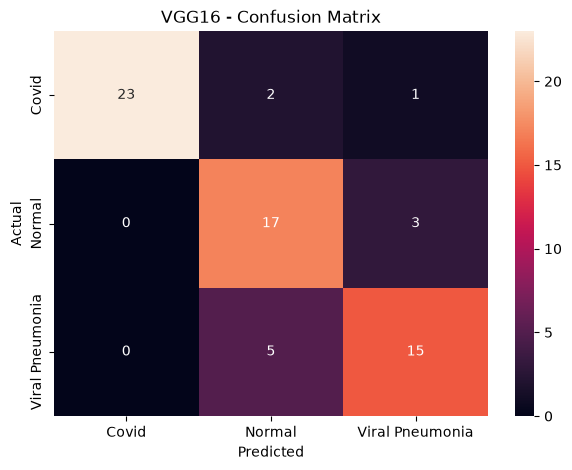

In [62]:
result_vgg = evaluate_model(
    vgg_model,
    X_test * 255.0,
    y_test,
    y_test_cat,
    "VGG16"
)

In [63]:
results = pd.DataFrame([
    result_basic,
    result_deep,
    result_resnet,
    result_vgg
])

results

,Model,Test Accuracy,F1 Score,ROC-AUC
0,Basic CNN,0.893939,0.895098,0.970694
1,Deep CNN,0.393939,0.222661,0.530909
2,ResNet50,0.969697,0.969621,0.996377
3,VGG16,0.833333,0.837081,0.948551


In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "Deep CNN",
        "VGG16",
        "ResNet50"
    ],

    "Train Accuracy": [
        max(history_basic.history["accuracy"]),
        max(history_deep.history["accuracy"]),
        max(history_vgg.history["accuracy"]),
        max(history_resnet.history["accuracy"])
    ],

    "Test Accuracy": [
        result_basic["Test Accuracy"],
        result_deep["Test Accuracy"],
        result_vgg["Test Accuracy"],
        result_resnet["Test Accuracy"]
    ],

    "F1 Score": [
        result_basic["F1 Score"],
        result_deep["F1 Score"],
        result_vgg["F1 Score"],
        result_resnet["F1 Score"]
    ]
})

comparison

,Model,Train Accuracy,Test Accuracy,F1 Score
0,Basic CNN,0.995,0.893939,0.895098
1,Deep CNN,0.885,0.393939,0.222661
2,VGG16,0.790,0.833333,0.837081
3,ResNet50,0.980,0.969697,0.969621


In [66]:
import keras_tuner as kt

In [67]:
def build_tuned_model(hp):

    model = keras.Sequential()

    model.add(
        layers.Input(
            shape=(224, 224, 3)
        )
    )

    filters = hp.Choice(
        "filters",
        values=[16, 32, 64]
    )

    model.add(
        layers.Conv2D(
            filters,
            (3, 3),
            activation="relu"
        )
    )

    model.add(
        layers.MaxPooling2D()
    )

    model.add(
        layers.Flatten()
    )

    units = hp.Choice(
        "dense_units",
        values=[64, 128, 256]
    )

    model.add(
        layers.Dense(
            units,
            activation="relu"
        )
    )

    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.6,
        step=0.1
    )

    model.add(
        layers.Dropout(dropout)
    )

    model.add(
        layers.Dense(
            3,
            activation="softmax"
        )
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            1e-3,
            1e-4,
            1e-5
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [68]:
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=5,
    directory="keras_tuner",
    project_name="covid_cnn"
)

In [71]:
tuner.search(
    X_train,
    y_train_cat,
    validation_data=(
        X_val,
        y_val_cat
    ),
    epochs=10
)

Trial 5 Complete [00h 00m 47s]
val_accuracy: 0.9607843160629272

Best val_accuracy So Far: 0.9607843160629272
Total elapsed time: 00h 06m 54s


In [72]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

d:\CNN mini project\myenv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


In [74]:
import os

os.makedirs("models", exist_ok=True)

In [75]:
resnet_model.save(
    "models/covid_model.keras"
)